In [1]:
import polars as pl

In [2]:
df = pl.read_parquet("final_patient_data.parquet")

In [19]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [4]:
patient = pl.read_parquet("patient.parquet")

In [5]:
patient.head()

patient_id,centre,gender,birth_date,internal_death_date,external_death_date,last_seen_date
str,str,str,date,date,date,date
"""P001""","""angers""","""F""",1933-04-12,2018-09-21,null,2018-09-21
"""P002""","""brest""","""M""",1934-11-03,null,null,2021-06-14
"""P003""","""nantes""","""F""",1935-07-26,null,2020-12-04,2020-12-04
"""P004""","""tours""","""M""",1936-02-18,null,null,2021-11-30
"""P005""","""angers""","""F""",1937-09-09,2019-03-17,null,2019-03-17


In [6]:
df_surv = df.join(patient.select(pl.col(["patient_id", "last_seen_date"])), on = "patient_id", how = "left")

In [7]:
df_surv.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,last_seen_date
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,date
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,2018-09-21


In [8]:
cv_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC",
]

In [9]:
df_surv = df_surv.with_columns(
    (
        pl.sum_horizontal([pl.col(c) for c in cv_cols]) >= 1
    )
    .cast(pl.Int8)
    .alias("cv_history")
)

In [20]:
df_surv.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,last_seen_date,cv_history,event,end_followup,time_to_event_days
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,datetime[μs],i32,f64,f64,i8,i32,datetime[μs],i8,i8,datetime[μs],i64
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21 00:00:00,85,0.0,0.0,2,1,2018-09-21 00:00:00,1,1,2018-09-21 00:00:00,78


In [11]:
df_surv = df_surv.with_columns(
    pl.col("hosp_admission_datetime").cast(pl.Datetime),
    pl.col("death_date").cast(pl.Datetime),
    pl.col("last_seen_date").cast(pl.Datetime),
)

In [12]:
df_surv = df_surv.with_columns(
    # event = 1 if death is observed
    pl.col("death_date").is_not_null().cast(pl.Int8).alias("event"),

    # end of follow-up:
    # if patient died -> death_date
    # otherwise -> last_seen_date
    pl.coalesce([
        pl.col("death_date"),
        pl.col("last_seen_date")
    ]).alias("end_followup")
)

In [13]:
df_surv = df_surv.with_columns(
    (
        (pl.col("end_followup") - pl.col("hosp_admission_datetime"))
        .dt.total_days()
    ).alias("time_to_event_days")
)

In [ ]:
n_before = df_surv.height

n_missing_time = df_surv.filter(
    pl.col("time_to_event_days").is_null()
).height

n_negative_time = df_surv.filter(
    pl.col("time_to_event_days") < 0
).height

print("Before filtering:", n_before)
print("Missing time_to_event_days:", n_missing_time)
print("Negative time_to_event_days:", n_negative_time)

In [14]:
df_surv = df_surv.filter(
    pl.col("time_to_event_days").is_not_null() &
    (pl.col("time_to_event_days") >= 0)
)

n_after = df_surv.height
print("After filtering:", n_after)
print("Removed:", n_before - n_after)

In [15]:
df_pd = df_surv.select([
    "patient_id",
    "time_to_event_days",
    "event",
    "cv_history"
]).to_pandas()

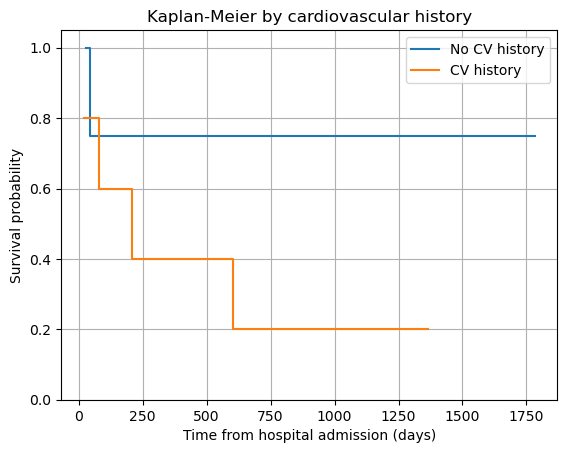

In [23]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

for group_value, group_df in df_pd.groupby("cv_history"):

    time, survival_prob = kaplan_meier_estimator(
        group_df["event"].astype(bool),
        group_df["time_to_event_days"]
    )

    label = "CV history" if group_value == 1 else "No CV history"

    plt.step(
        time,
        survival_prob,
        where="post",
        label=label
    )

plt.xlabel("Time from hospital admission (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier by cardiovascular history")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()